<a href="https://colab.research.google.com/github/Thujaina/ECG-classification----Res-Net/blob/main/poly1_cross_entropy(need_improve).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import Conv1D, MaxPooling1D, Dense, BatchNormalization, GlobalAveragePooling1D
from keras.layers import Add, Input
from keras.models import Model

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


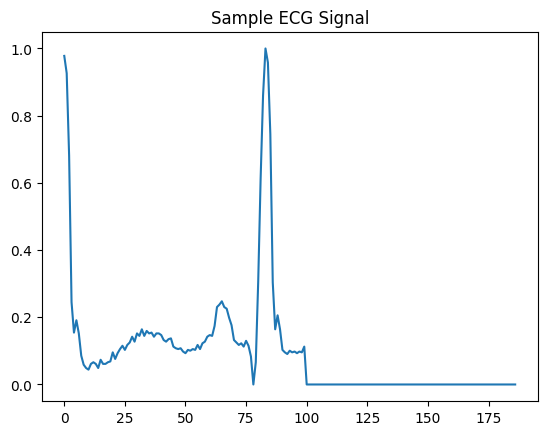

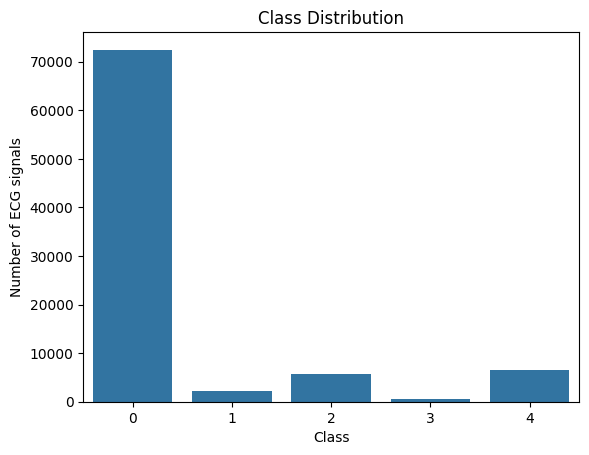

0
0


In [34]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

print(train.isna().sum().sum())
print(test.isna().sum().sum())

In [35]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]


In [36]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [37]:
y_res_sparse = y_res
y_test_sparse = y_test

X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [38]:
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE

kfold = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

cv_accuracies = []

# Use ORIGINAL data here
X_original = np.array(X_train)
y_original = np.array(y_train)

for fold, (train_idx, val_idx) in enumerate(
    kfold.split(X_original, y_original)
):

    print(f"\nFold {fold+1}")

    X_tr = X_original[train_idx]
    y_tr = y_original[train_idx]

    X_va = X_original[val_idx]
    y_va = y_original[val_idx]

    # SMOTE ONLY ON TRAINING FOLD
    smote = SMOTE(random_state=42)

    X_tr, y_tr = smote.fit_resample(
        X_tr,
        y_tr
    )

    X_tr = X_tr.reshape(-1, 187, 1)
    X_va = X_va.reshape(-1, 187, 1)

    y_tr = tf.keras.utils.to_categorical(y_tr, 5)
    y_va = tf.keras.utils.to_categorical(y_va, 5)

    model = resnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(
        X_va,
        y_va,
        verbose=0
    )

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))
print("Std CV accuracy:", np.std(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 55s 11ms/step - accuracy: 0.9369 - loss: 0.2777
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - accuracy: 0.9759 - loss: 0.1110
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9845 - loss: 0.0724
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - accuracy: 0.9888 - loss: 0.0534
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.9913 - loss: 0.0409
Fold 1 Accuracy: 0.7860

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 56s 11ms/step - accuracy: 0.9363 - loss: 0.2801
Epoch 2/5
 584/3775 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - accuracy: 0.9694 - loss: 0.1391

KeyboardInterrupt: 

In [39]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)

    return x


def poly1_loss(y_true, y_pred, epsilon=1.0):

    y_true = tf.cast(y_true, tf.float32)

    y_pred = tf.clip_by_value(
        y_pred,
        1e-7,
        1.0 - 1e-7
    )

    ce = tf.keras.losses.categorical_crossentropy(
        y_true,
        y_pred
    )

    pt = tf.reduce_sum(y_true * y_pred, axis=-1)

    poly1 = ce + epsilon * (1 - pt)

    return tf.reduce_mean(poly1)


def resnet_ecg():

    inputs = Input(shape=(187, 1))

    x = Conv1D(32, 3, activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x, 64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x, 128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x, 256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss=poly1_loss,
        metrics=['accuracy']
    )

    return model

In [40]:
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE

kfold = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

cv_accuracies = []

# Use ORIGINAL data here
X_original = np.array(X_train)
y_original = np.array(y_train)

for fold, (train_idx, val_idx) in enumerate(
    kfold.split(X_original, y_original)
):

    print(f"\nFold {fold+1}")

    X_tr = X_original[train_idx]
    y_tr = y_original[train_idx]

    X_va = X_original[val_idx]
    y_va = y_original[val_idx]

    # SMOTE ONLY ON TRAINING FOLD
    smote = SMOTE(random_state=42)

    X_tr, y_tr = smote.fit_resample(
        X_tr,
        y_tr
    )

    X_tr = X_tr.reshape(-1, 187, 1)
    X_va = X_va.reshape(-1, 187, 1)

    y_tr = tf.keras.utils.to_categorical(y_tr, 5)
    y_va = tf.keras.utils.to_categorical(y_va, 5)

    model = resnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(
        X_va,
        y_va,
        verbose=0
    )

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))
print("Std CV accuracy:", np.std(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 60s 11ms/step - accuracy: 0.9349 - loss: 0.2857
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9742 - loss: 0.1165
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - accuracy: 0.9838 - loss: 0.0747
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9887 - loss: 0.0530
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - accuracy: 0.9913 - loss: 0.0410
Fold 1 Accuracy: 0.9647

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 55s 11ms/step - accuracy: 0.9396 - loss: 0.2667
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - accuracy: 0.9761 - loss: 0.1096
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9844 - loss: 0.0708
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - accuracy: 0.9891 - loss: 0.0503
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9914 - loss: 0.0399
Fold 2 Accuracy: 0.9575

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 55s 1

In [41]:
from tensorflow.keras.utils import to_categorical
# Reshape full SMOTE-resampled data for training
X_res_reshaped = np.array(X_res).reshape(-1, 187, 1)
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

# Split for validation (optional, you can use full train data too)
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res_reshaped, y_res_cat, test_size=0.2, random_state=42
)

In [43]:
# Create the ResNet model
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import Dropout
model = resnet_ecg()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 73s 12ms/step - accuracy: 0.9339 - loss: 0.2927 - val_accuracy: 0.9172 - val_loss: 0.3589
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 49s 11ms/step - accuracy: 0.9728 - loss: 0.1228 - val_accuracy: 0.9653 - val_loss: 0.1525
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.9834 - loss: 0.0764 - val_accuracy: 0.7707 - val_loss: 1.2582
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 48s 11ms/step - accuracy: 0.9882 - loss: 0.0557 - val_accuracy: 0.7121 - val_loss: 1.4537
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9906 - loss: 0.0445 - val_accuracy: 0.9914 - val_loss: 0.0434
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.9926 - loss: 0.0349 - val_accuracy: 0.9872 - val_loss: 0.0606
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.9940 - loss: 0.0289 - val_accuracy: 0.9745 - val_loss: 0.1305
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.9949 -

In [44]:
# Evaluate on validation set
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)
y_val_true = np.argmax(y_val_final, axis=1)
mcc_val = matthews_corrcoef(y_val_true, y_val_pred)
print("Validation MCC:", mcc_val)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step
Validation MCC: 0.9922219562033723


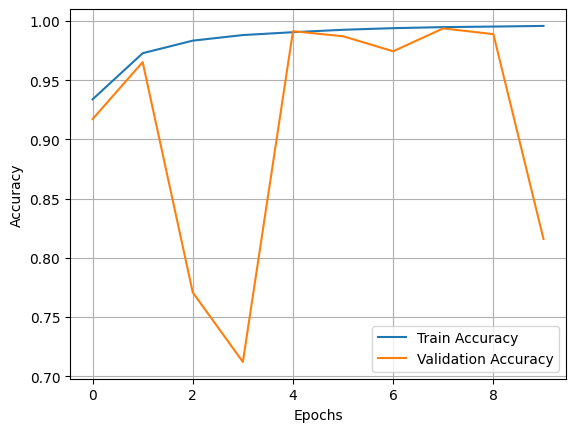

In [45]:
# Plot training/validation accuracy
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

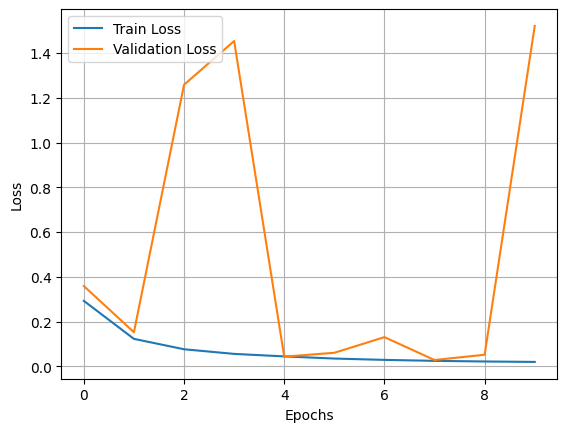

In [46]:
# Plot training/validation loss
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [47]:
# Final training & validation metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

Final Training Accuracy: 0.9959
Final Validation Accuracy: 0.8160
Final Training Loss: 0.0198
Final Validation Loss: 1.5212


In [48]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Test set classification report
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

Test Loss: 0.1289
Test Accuracy: 0.9790
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     18118
         1.0       0.76      0.78      0.77       556
         2.0       0.97      0.94      0.95      1448
         3.0       0.75      0.81      0.78       162
         4.0       0.99      0.98      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.89      0.90      0.90     21892
weighted avg       0.98      0.98      0.98     21892



685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


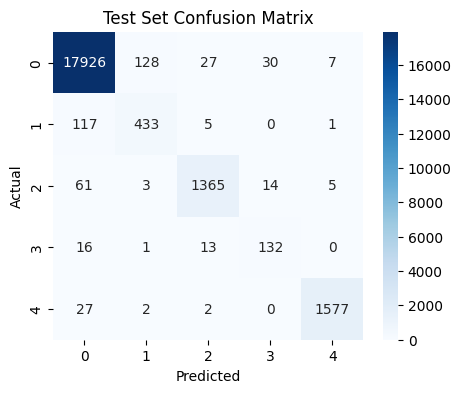

In [49]:
# Test set predictions
y_test_pred = np.argmax(model.predict(X_test), axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set Confusion Matrix")
plt.show()

In [50]:
print("TRAIN_PATH =", TRAIN_PATH)
print("TEST_PATH  =", TEST_PATH)

TRAIN_PATH = /content/drive/MyDrive/datasets/ECG/mitbih_train.csv
TEST_PATH  = /content/drive/MyDrive/datasets/ECG/mitbih_test.csv


In [51]:
val_loss, val_acc = model.evaluate(
    X_val_final,
    y_val_final,
    verbose=0
)

print("Actual Validation Accuracy:", val_acc)

Actual Validation Accuracy: 0.993776798248291
